<a href="https://colab.research.google.com/github/dwelle511/2026BDA/blob/main/PandasCookbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## idioms

In [ ]:
import pandas as pd
df=pd.DataFrame(
    {"AAA":[4,5,6,7],"BBB":[10,20,30,40],"CCC":[100,50,-30,-50]}


)
df

,AAA,BBB,CCC
0,4,10,100
1,5,20,50
2,6,30,-30
3,7,40,-50


In [ ]:
#if-then: an if-then one one column
df.loc[df.AAA>=5,"BBB"]=-1
df

,AAA,BBB,CCC
0,4,2000,2000
1,5,-1,555
2,6,-1,555
3,7,-1,555


In [ ]:
#an if-then with assignment to 2 columns
df.loc[df.AAA>=5,["BBB","CCC"]]=555
df

,AAA,BBB,CCC
0,4,2000,2000
1,5,555,555
2,6,555,555
3,7,555,555


In [ ]:
#add another line with difference logic, to do the -else
df.loc[df.AAA<5,["BBB","CCC"]]=2000
df

,AAA,BBB,CCC
0,4,2000,2000
1,5,555,555
2,6,555,555
3,7,555,555


In [ ]:
#or use pandas where after you've set up a mark
df_mask=pd.DataFrame(
    {"AAA":[True]*4,"BBB":[False]*4,"CCC":[True,False]*2}

)
df.where(df_mask,-1000) #false 에 뭔가 변경을 하는거 같은데 , where인가

,AAA,BBB,CCC
0,4,-1000,2000
1,5,-1000,-1000
2,6,-1000,555
3,7,-1000,-1000


In [ ]:
#Series.where(), DataFrame.where() , diffrent from the
s=pd.Series(range(5))
s.where(s>0)
# .where() : if the condition correct return the value, if condition differ return the NAN

,0
0,NaN
1,1.0
2,2.0
3,3.0
4,4.0


In [ ]:
s.mask(s>0)
#apposite with .where()

,0
0,0.0
1,NaN
2,NaN
3,NaN
4,NaN


In [ ]:
s=pd.Series(range(5))
t=pd.Series([True,False])
s.where(t,99)

,0
0,0
1,99
2,99
3,99
4,99


In [ ]:
s.mask(t,99)

,0
0,99
1,1
2,99
3,99
4,99


In [ ]:
s.where(s>1,10)

,0
0,10
1,10
2,2
3,3
4,4


In [ ]:
s.mask(s>1,10)

,0
0,0
1,1
2,10
3,10
4,10


In [ ]:
import numpy as np
ss=pd.DataFrame(np.arange(10).reshape(-1,2),columns=["A","B"])
ss

,A,B
0,0,1
1,2,3
2,4,5
3,6,7
4,8,9


In [ ]:
m=ss%3==0

In [ ]:
ss.where(m,-ss)

,A,B
0,0,-1
1,-2,3
2,-4,-5
3,6,-7
4,-8,9


In [ ]:
ss.where(m,-ss)==np.where(m,ss,-ss)

,A,B
0,True,True
1,True,True
2,True,True
3,True,True
4,True,True


In [ ]:
ss.where(m,-ss)==ss.mask(-m,-ss)

,A,B
0,True,True
1,True,True
2,True,True
3,True,True
4,True,True


In [ ]:
df=pd.DataFrame(
    {"AAA":[4,5,6,7],"BBB":[10,20,30,40],"CCC":[100,50,-30,-50]}
)
df

,AAA,BBB,CCC
0,4,10,100
1,5,20,50
2,6,30,-30
3,7,40,-50


In [ ]:
df["logic"]=np.where(df["AAA"]>5,"higt","low")
df

,AAA,BBB,CCC,logic
0,4,10,100,low
1,5,20,50,low
2,6,30,-30,higt
3,7,40,-50,higt


In [ ]:
#Splitting: split the frame with a boolean criterion
df=pd.DataFrame(
    {"AAA":[4,5,6,7],"BBB":[10,20,30,40],"CCC":[100,50,-30,-50]}
)
df

,AAA,BBB,CCC
0,4,10,100
1,5,20,50
2,6,30,-30
3,7,40,-50


In [ ]:
df[df.AAA <=5]

,AAA,BBB,CCC
0,4,10,100
1,5,20,50


In [ ]:
df.iloc[0:2,:]

,AAA,BBB,CCC
0,4,10,100
1,5,20,50


In [ ]:
df[df.AAA >5]

,AAA,BBB,CCC
2,6,30,-30
3,7,40,-50


In [ ]:
#building criteria
## select with multi-column criteria

df=pd.DataFrame(
    {"AAA":[4,5,6,7],"BBB":[10,20,30,40],"CCC":[100,50,-30,-50]}

)
df

,AAA,BBB,CCC
0,4,10,100
1,5,20,50
2,6,30,-30
3,7,40,-50


In [ ]:
df.loc[(df["BBB"]<25) & (df["CCC"]>=-40),"AAA"]

,AAA
0,4
1,5


In [ ]:
df.loc[(df["BBB"]>25)| (df["CCC"]>=-40),"AAA"]

,AAA
0,4
1,5
2,6
3,7


In [ ]:
df.loc[(df["BBB"]>25)| (df["CCC"]>=75),"AAA"]=999
df

,AAA,BBB,CCC
0,999,10,100
1,5,20,50
2,999,30,-30
3,999,40,-50


In [ ]:
#select rows whit data  to certain value using argsort
df=pd.DataFrame(
    {"AAA":[4,5,6,7],"BBB":[10,20,30,40],"CCC":[100,50,-30,-50]}
)
df

,AAA,BBB,CCC
0,4,10,100
1,5,20,50
2,6,30,-30
3,7,40,-50


In [ ]:
aValue=43.0
df.loc[(df.CCC-aValue).abs().argsort()]

,AAA,BBB,CCC
1,5,20,50
0,4,10,100
2,6,30,-30
3,7,40,-50


In [ ]:
ex=pd.Series([3,2,1])
ex

,0
0,3
1,2
2,1


In [ ]:
ex.argsort() # 오름차순으로 정렬 한것 (만일 내림 차순 하고 싶으면 -> [::-1]넣기 )

,0
0,2
1,1
2,0


In [ ]:
#dynamic reduce a laist of criteria using a binary operation
df=pd.DataFrame(
    {"AAA":[4,5,6,7],"BBB":[10,20,30,40],"CCC":[100,50,-30,-50]}
)
df

,AAA,BBB,CCC
0,4,10,100
1,5,20,50
2,6,30,-30
3,7,40,-50


In [ ]:
Crit1=df.AAA <=5.5
Crit2=df.BBB ==10.0
Crit3=df.CCC > -40.0

In [ ]:
# one  could hard code
AllCrit= Crit1 & Crit2 & Crit3

In [ ]:
#Or it can be done with a list of dynamically built criteria
import functools

CritList=[Crit1,Crit2,Crit3]

AllCrit=functools.reduce(lambda x,y:x&y,CritList)

df[AllCrit]

,AAA,BBB,CCC
0,4,10,100


In [ ]:
#Selection
## DataFrames
### The indexing docs. Using both row labels and value conditionals
df=pd.DataFrame(
    {"AAA":[4,5,6,7],"BBB":[10,20,30,40],"CCC":[100,50,-30,-50]}
)
df

,AAA,BBB,CCC
0,4,10,100
1,5,20,50
2,6,30,-30
3,7,40,-50


In [ ]:
df[(df.AAA <=6) & (df.index.isin([0,2,4]))] #??? df.iloc[1,] 왜 포함이 아니지???

,AAA,BBB,CCC
0,4,10,100
2,6,30,-30


In [ ]:
#isin() : 데이터프레임 객체의 각 요소가 벨류 값과 일치여부를 bool형식으로 반환
#.index() : 리스트중에 특정 원소가 몇 번째에 처음으로 등장했는지 알려주는 함수
ex2=[10,20,30,40]
ex2.index(20)

1

In [ ]:
# use loc for label -oriented slicing and iloc positional slicing
df=pd.DataFrame(
    {"AAA":[4,5,6,7],"BBB":[10,20,30,40],"CCC":[100,50,-50,-30]},
    index=["foo","bar","boo","kar"]
)
df

,AAA,BBB,CCC
foo,4,10,100
bar,5,20,50
boo,6,30,-50
kar,7,40,-30


In [ ]:
#slicing method 3
# 1. Positional-oriented(python slicing style:exclusive of end)
# 2.Label-oriented (non-pyhton slicign style : inclusive of end)
# 3. General(Either slicing style : depends on if the slice contins lebels or position)
df.loc["bar":"kar"]

,AAA,BBB,CCC
bar,5,20,50
boo,6,30,-50
kar,7,40,-30


In [ ]:
#ambiguity arises when an index consists of integer with a non-zero start or non-unit increment
data={"AAA":[4,5,6,7],"BBB":[10,20,30,40],"CCC":[100,50,-30,-50]}
df2=pd.DataFrame(data=data,index=[1,2,3,4])
df2.iloc[1:3]

,AAA,BBB,CCC
2,5,20,50
3,6,30,-30


In [ ]:
# Using inverse operator(~) to take the complement of mask
df = pd.DataFrame(
    {"AAA": [4, 5, 6, 7], "BBB": [10, 20, 30, 40], "CCC": [100, 50, -30, -50]}
)
df[~((df.AAA <=6)& (df.index.isin([0,2,4])))]

,AAA,BBB,CCC
1,5,20,50
3,7,40,-50


In [ ]:
#New columns
# Efficiently and dynamically creating new columns using DataFrame.map(previously named applymap)
df=pd.DataFrame({"AAA":[1,2,1,3],"BBB":[1,1,2,2],"CCC":[2,1,3,1]})
df

,AAA,BBB,CCC
0,1,1,2
1,2,1,1
2,1,2,3
3,3,2,1


In [ ]:
source_cols=df.columns

In [ ]:
new_cols=[str(x)+"_cat" for x in source_cols]
categories={1:"Alpha",2:"Beta",3:"Charlie"}
df[new_cols]=df[source_cols].map(categories.get)
df

,AAA,BBB,CCC,AAA_cat,BBB_cat,CCC_cat
0,1,1,2,Alpha,Alpha,Beta
1,2,1,1,Beta,Alpha,Alpha
2,1,2,3,Alpha,Beta,Charlie
3,3,2,1,Charlie,Beta,Alpha


In [ ]:
#.map: 여러개의 데이터 받아 각각의 요소에 함수를 적용한 결고를 반환하는 내장 함수
# 리스트, 튜플 등의 반복 가능한 iterable 객체 입력 받기 가능
#  map(function, iterable) :함수, 함수에 적용할 요소의 데이터 집합
def square(x):
  return x**2
num=[1,2,3,4]
squared_num=map(square,num)
print(list(squared_num))

[1, 4, 9, 16]


In [ ]:
#keep other columns when using min() with groupby
import pandas as pd
df=pd.DataFrame(
    {"AAA":[1,1,1,2,2,2,3,3],"BBB":[2,1,3,4,5,1,2,3]}
)
df

,AAA,BBB
0,1,2
1,1,1
2,1,3
3,2,4
4,2,5
5,2,1
6,3,2
7,3,3


In [ ]:
#method1 : idxmin() to get the index of the minimums
df.loc[df.groupby("AAA")["BBB"].idxmin()]

,AAA,BBB
1,1,1
5,2,1
6,3,2


In [ ]:
df.groupby(["AAA"]).idxmin()

,BBB
AAA,
1,1
2,5
3,6


In [ ]:
#method2 : sort then take first of each
df.sort_values(by="BBB").groupby("AAA",as_index=False).first()

,AAA,BBB
0,1,1
1,2,1
2,3,2


In [ ]:
#### multiindexing
## the multindexing odcs, create a multindex from a labeled frame
df=pd.DataFrame(
    {
    "row": [0,1,2],
    "One_X":[1.1,1.1,1.1],
    "One_Y":[1.2,1.2,1.2],
    "Two_X":[1.11,1.11,1.11],
    "Two_Y":[1.22,1.22,1.22],
    }
)
df

,row,One_X,One_Y,Two_X,Two_Y
0,0,1.1,1.2,1.11,1.22
1,1,1.1,1.2,1.11,1.22
2,2,1.1,1.2,1.11,1.22


In [ ]:
#as labelled index
df=df.set_index("row")
#.set_index() : 데이터프레임의 기존 열을 새로운 인텍스로 설정하여, 더 효율적으로 관리하고 조회할 때 사용

In [ ]:
df

,One_X,One_Y,Two_X,Two_Y
row,,,,
0,1.1,1.2,1.11,1.22
1,1.1,1.2,1.11,1.22
2,1.1,1.2,1.11,1.22


In [ ]:
#with hierarchical columns
df.columns=pd.MultiIndex.from_tuples([tuple(c.split("_")) for c in df.columns])
df
#??
#from_tuple() :

One        Two      
       X    Y     X     Y
row                      
0    1.1  1.2  1.11  1.22
1    1.1  1.2  1.11  1.22
2    1.1  1.2  1.11  1.22

In [ ]:
#now stack & reset
df=df.stack(0).reset_index(1)
df
#.reset_index() : 기존 인덱스 열로 추가하지 않고 삭제
#.stack(0): ??

/tmp/ipykernel_15483/1984910100.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df=df.stack(0).reset_index(1)


,level_1,X,Y
row,,,
0,One,1.10,1.20
0,Two,1.11,1.22
1,One,1.10,1.20
1,Two,1.11,1.22
2,One,1.10,1.20
2,Two,1.11,1.22


In [ ]:
#and fix the labels (Notice the label 'level_1' got added automatically)
df.columns=["Sample","All_X","All_Y"]
df

,Sample,All_X,All_Y
row,,,
0,One,1.10,1.20
0,Two,1.11,1.22
1,One,1.10,1.20
1,Two,1.11,1.22
2,One,1.10,1.20
2,Two,1.11,1.22


In [ ]:
#### Arithmetic
# Performing arithmetic with a Multindexing that needs broadcasting
import numpy as np
cols=pd.MultiIndex.from_tuples(
    [(x,y) for x in ["A","B","C"] for y in ["O","I"]]
)
df=pd.DataFrame(np.random.randn(2,6), index=["n","m"],columns=cols)
df

A                   B                   C          
          O         I         O         I         O         I
n -0.834500  0.495976  0.575643  0.516685  0.355677  0.715500
m -0.065286 -1.679369  1.937113  1.521821 -0.221553  0.459026

In [ ]:
#### Slicing
## Slicing a MultiIndex with xs
coords=[("AA","one"),("AA","six"),("BB","one"),("BB","two"),("BB","six")]
index=pd.MultiIndex.from_tuples(coords)
df=pd.DataFrame([11,22,33,44,55],index,["MyData"])
df

MyData
AA one      11
   six      22
BB one      33
   two      44
   six      55

In [ ]:
# To take the cross section if the 1st level axis the index
# Note: level and axis are optional, and default to zere
df.xs("BB",level=0,axis=0)

# .xs() : 인덱스 계층 구조 내에서 특정 값(key)를 가진 행이나 열을 간편하게 조회함


,MyData
one,33
two,44
six,55


In [ ]:
# and now the 2ne level of the 1st axis
df.xs("six",level=1,axis=0)

,MyData
AA,22
BB,55


In [ ]:
# Slicing a MultiIndex with xs, method #2
import itertools
import pandas as pd
index=list(itertools.product(["Ada","Quinn","Violet"],["Comp","Math","Sci"]))
headr=list(itertools.product(["Exams","Labs"],["I","II"]))

indx=pd.MultiIndex.from_tuples(index,names=["Student","Course"])
cols=pd.MultiIndex.from_tuples(headr) #Notice these are un-named

data=[[70+x+y+(x*y)%3 for x in range(4)] for y in range(9)]

df=pd.DataFrame(data,indx,cols)
df

Exams     Labs    
                   I  II    I  II
Student Course                   
Ada     Comp      70  71   72  73
        Math      71  73   75  74
        Sci       72  75   75  75
Quinn   Comp      73  74   75  76
        Math      74  76   78  77
        Sci       75  78   78  78
Violet  Comp      76  77   78  79
        Math      77  79   81  80
        Sci       78  81   81  81

In [ ]:
All=slice(None)

In [ ]:
df.loc["Violet"]

Exams     Labs    
           I  II    I  II
Course                   
Comp      76  77   78  79
Math      77  79   81  80
Sci       78  81   81  81

In [ ]:
df.loc[(All,"Math"),All]

Exams     Labs    
                   I  II    I  II
Student Course                   
Ada     Math      71  73   75  74
Quinn   Math      74  76   78  77
Violet  Math      77  79   81  80

In [ ]:
df.loc[(slice("Ada","Quinn"),"Math"),All]

Exams     Labs    
                   I  II    I  II
Student Course                   
Ada     Math      71  73   75  74
Quinn   Math      74  76   78  77

In [ ]:
df.loc[(All,"Math"),("Exams")]

,,I,II
Student,Course,,
Ada,Math,71,73
Quinn,Math,74,76
Violet,Math,77,79


In [ ]:
df.loc[(All,"Math"),(All,"II")]

,,Exams,Labs
,,II,II
Student,Course,,
Ada,Math,73,74
Quinn,Math,76,77
Violet,Math,79,80


In [ ]:
#### Sorting
# Sort by specific column or an ordered list of columns,with a MultiIndex
df.sort_values(by=("Labs","II"),ascending=False)

Exams     Labs    
                   I  II    I  II
Student Course                   
Violet  Sci       78  81   81  81
        Math      77  79   81  80
        Comp      76  77   78  79
Quinn   Sci       75  78   78  78
        Math      74  76   78  77
        Comp      73  74   75  76
Ada     Sci       72  75   75  75
        Math      71  73   75  74
        Comp      70  71   72  73

In [ ]:
#### Missing Data
### The missing data docs
# Fit forward a reversed timeseries
import numpy as np
import pandas as pd
df=pd.DataFrame(
    np.random.randn(6,1),
    index=pd.date_range("2013-08-01",periods=6,freq="B"),
    columns=list("A"),

)
df.loc[df.index[3],"A"]=np.nan
df

,A
2013-08-01,-0.301094
2013-08-02,-0.532478
2013-08-05,3.214443
2013-08-06,NaN
2013-08-07,-0.268904
2013-08-08,0.646149


In [ ]:
df.bfill()

,A
2013-08-01,-0.301094
2013-08-02,-0.532478
2013-08-05,3.214443
2013-08-06,-0.268904
2013-08-07,-0.268904
2013-08-08,0.646149


In [ ]:
##### Grouping
## The grouping docs.
# Basic grouping with apply, Unlikeagg, apply's callable is passed a sub-DataFrame when gives you access to all the columns
df=pd.DataFrame(
    {
        "animal":"cat dog cat fish dog cat cat".split(),
        "size":list("SSMMMLL"),
        "weight":[8,10,11,1,20,12,12],
        "adult":[False]*5+[True]*2,
    }
)
df

,animal,size,weight,adult
0,cat,S,8,False
1,dog,S,10,False
2,cat,M,11,False
3,fish,M,1,False
4,dog,M,20,False
5,cat,L,12,True
6,cat,L,12,True


In [ ]:
#The list size of the animals with the highest weight
df.groupby("animal").apply(lambda subf:subf["size"][subf["weight"].idxmax()])

#subf :

/tmp/ipykernel_1386/672720082.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("animal").apply(lambda subf:subf["size"][subf["weight"].idxmax()])


,0
animal,
cat,L
dog,M
fish,M


In [ ]:
# listing get_group
gb=df.groupby("animal")
gb.get_group("cat")

,animal,size,weight,adult
0,cat,S,8,False
2,cat,M,11,False
5,cat,L,12,True
6,cat,L,12,True


In [ ]:
#apply to different items in a group
def GrowUp(x):
  avg_weight=sum(x[x["size"]=="S"].weight*1.5)
  avg_weight +=sum(x[x["size"]== "M"].weight*1.25)
  avg_weight += sum(x[x["size"]=="L"].weight)
  avg_weight /= len(x)
  return pd.Series(["L",avg_weight,True],index=["size","weight","adult"])

expected_df=gb.apply(GrowUp)
expected_df
#오류난 이유 1.size의 L대신 딴거 오타로 사용 2.expected_df 들여쓰기로 def에 포함시켜버림

/tmp/ipykernel_1386/3987990647.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  expected_df=gb.apply(GrowUp)


,size,weight,adult
animal,,,
cat,L,12.4375,True
dog,L,20.0000,True
fish,L,1.2500,True


In [ ]:
# expanding apply
S=pd.Series([i/ 100.0 for i in range(1,11)])
def cum_ret(x,y):
  return x*(1+y)

def red(x):
  return functools.reduce(cum_ret,x,1.0)

S.expanding().apply(red,raw=True)
#apply()

NameError: name 'functools' is not defined

In [ ]:
#Replace some value with mean of the rest of a group
df=pd.DataFrame({"A":[1,1,2,2],"B":[1,-1,1,2]})
gb=df.groupby("A")
def replace(g):
  mask=g<0
  return g.where(~mask,g[~mask].mean())
gb.transform(replace)

,B
0,1
1,1
2,1
3,2


In [ ]:
#Sort groups by aggregated data
df=pd.DataFrame({
    "code":["foo","bar","baz"]*2,
    "data":[0.16,-0.21,0.33,0.45,-0.59,0.62],
    "flag":[False,True]*3,
})
df

,code,data,flag
0,foo,0.16,False
1,bar,-0.21,True
2,baz,0.33,False
3,foo,0.45,True
4,bar,-0.59,False
5,baz,0.62,True


In [ ]:
code_groups=df.groupby("code")

In [ ]:
agg_n_sort_order=code_groups[["data"]].transform("sum").sort_values(by="data")

In [ ]:
sorted_df=df.loc[agg_n_sort_order.index]
sorted_df

,code,data,flag
1,bar,-0.21,True
4,bar,-0.59,False
3,foo,0.45,True
0,foo,0.16,False
2,baz,0.33,False
5,baz,0.62,True


In [ ]:
#create multiple aggregated columns
#error: date 입력시 2020-12-12 아래밑줄 말고 그냥 슬래시 사용
rng=pd.date_range(start="2026-05-17",periods=10,freq="2min")
ts=pd.Series(data=list(range(10)),index=rng)
def MyCust(x):
  if len(x)>2:
    return x.iloc[1]*1.234
  return pd.NaT
mhc={"Mean":"mean","Max":"max","Custom":MyCust}
ts.resample("5min").apply(mhc)
#NaT: Not A Time , similar with Nan

,Mean,Max,Custom
2026-05-17 00:00:00,1.0,2,1.234
2026-05-17 00:05:00,3.5,4,NaT
2026-05-17 00:10:00,6.0,7,7.404
2026-05-17 00:15:00,8.5,9,NaT


In [ ]:
ts

,0
2026-05-17 00:00:00,0
2026-05-17 00:02:00,1
2026-05-17 00:04:00,2
2026-05-17 00:06:00,3
2026-05-17 00:08:00,4
2026-05-17 00:10:00,5
2026-05-17 00:12:00,6
2026-05-17 00:14:00,7
2026-05-17 00:16:00,8
2026-05-17 00:18:00,9


In [ ]:
#create a value counts column and reassign back to the DataFrame
df=pd.DataFrame(
    {"Color":"Red Red Red Blue".split(),"Value":[100,150,50,50]}
)
df

,Color,Value
0,Red,100
1,Red,150
2,Red,50
3,Blue,50


In [ ]:
df["Counts"]=df.groupby(["Color"]).transform(len)
df

,Color,Value,Counts
0,Red,100,3
1,Red,150,3
2,Red,50,3
3,Blue,50,1


In [ ]:
#Shift groups of the values in a column based on the index
df=pd.DataFrame(
    {"line_race":[10,10,8,10,10,8],"beyer":[99,102,103,103,88,100]},
    index=[
        "Last Gunfighter",
        "Last Gunfighter",
        "Last Gunfighter",
        "Paynter",
        "Paynter",
        "Paynter"
    ],
)
df

,line_race,beyer
Last Gunfighter,10,99
Last Gunfighter,10,102
Last Gunfighter,8,103
Paynter,10,103
Paynter,10,88
Paynter,8,100


In [ ]:
df["beyer_shifted"]=df.groupby(level=0)["beyer"].shift(1)
df
#왜 NaN이 나온거지

,line_race,beyer,beyer_shifted
Last Gunfighter,10,99,NaN
Last Gunfighter,10,102,99.0
Last Gunfighter,8,103,102.0
Paynter,10,103,NaN
Paynter,10,88,103.0
Paynter,8,100,88.0


In [ ]:
#select row with maximun value from each group
df=pd.DataFrame(
    {
        "host":["other","other","that","this","this"],
        "service":["mail","web","mail","mail","web"],
        "no":[1,2,1,2,1],
    }
).set_index(["host","service"])
df
#set_index(["row1","row2"]) : 멀티인덱스가 행에 있는 느낌

no
host  service    
other mail      1
      web       2
that  mail      1
this  mail      2
      web       1

In [ ]:
mask=df.groupby(level=0).agg("idxmax")
df_count=df.loc[mask["no"]].reset_index()

df_count

,host,service,no
0,other,web,2
1,that,mail,1
2,this,mail,2


In [ ]:
#Grouping like Python's itertools groupby
df=pd.DataFrame([0,1,0,1,1,1,0,1,1],columns=["A"])
df["A"].groupby((df["A"].shift()).cumsum()).groups
df["A"].groupby((df["A"]!=df["A"].shift()).cumsum()).cumsum()

,A
0,0
1,1
2,0
3,1
4,2
5,3
6,0
7,1
8,2


In [ ]:
np.random.rand(2)

array([0.01128004, 0.22597054])

In [ ]:
### Splitting
## Create a list of dataframes,split using a delineation based on logic included in rows
import pandas as pd
import numpy as np
df=pd.DataFrame(
    data={
        "Case":["A","A","A","B","A","A","B","A","A"],
        "Data":np.random.randn(9),
    }
)
dfs=list(
    zip(
        *df.groupby(
            (1*(df["Case"]=="8"))
            .cumsum()
            .rolling(window=3,min_periods=1)
            .median()
        )
    )
)[-1]

In [ ]:
dfs[0]

,Case,Data
0,A,2.116912
1,A,1.202275
2,A,0.988060
3,B,1.341638
4,A,-0.945206
5,A,-0.359120
6,B,-1.578699
7,A,0.875105
8,A,-0.918085


In [ ]:
dfs[2]

IndexError: tuple index out of range

In [ ]:
### Pivot
## The Pivot docs
# Partial sums and subtotals

df=pd.DataFrame(
    data={
        "Province":["ON","QC","BC","AL","AL","MN","ON"],
        "City":[
            "Toronto",
            "Montreal",
            "Vancouver",
            "Calgary",
            "Edmonton",
            "Winnipeg",
            "Windsor",
        ],
        "Sales":[13,6,16,8,4,3,1],
    }
)
df

,Province,City,Sales
0,ON,Toronto,13
1,QC,Montreal,6
2,BC,Vancouver,16
3,AL,Calgary,8
4,AL,Edmonton,4
5,MN,Winnipeg,3
6,ON,Windsor,1


In [ ]:
table=pd.pivot_table(
    df,
    values=["Sales"],
    index=["Province"],
    columns=["City"],
    aggfunc="sum",
    margins=True,
)
table.stack("City")

/tmp/ipykernel_2272/2462296634.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  table.stack("City")


Sales
Province City            
AL       Calgary      8.0
         Edmonton     4.0
         All         12.0
BC       Vancouver   16.0
         All         16.0
MN       Winnipeg     3.0
         All          3.0
ON       Toronto     13.0
         Windsor      1.0
         All         14.0
QC       Montreal     6.0
         All          6.0
All      Calgary      8.0
         Edmonton     4.0
         Montreal     6.0
         Toronto     13.0
         Vancouver   16.0
         Windsor      1.0
         Winnipeg     3.0
         All         51.0

In [ ]:
#Frequency table like plyr in R
grades=[48,99,75,80,42,80,72,68,36,78]
df=pd.DataFrame(
    {
        "ID":["x%d" % r for r in range(10)],
        "Gender":["F","M","F","M","F","M","F","M","M","M"],
        "ExamYear":[
            "2007",
            "2007",
            "2007",
            "2008",
            "2008",
            "2008",
            "2008",
            "2009",
            "2009",
            "2009"
        ],
        "Class":[
            "algebra",
            "stats",
            "bio",
            "algebra",
            "algebra",
            "stats",
            "stats",
            "algebra",
            "bio",
            "bio",
        ],
        "Participated":[
            "yes",
            "yes",
            "yes",
            "yes",
            "no",
            "yes",
            "yes",
            "yes",
            "yes",
            "yes",

        ],
        "Passed":["yes" if x>50 else "no" for x in grades],
        "Employed":[
            True,
            True,
            True,
            False,
            False,
            False,
            False,
            True,
            True,
            False,
        ],
        "Grade":grades,

    }
)

In [ ]:
df.groupby("ExamYear").agg(
    {
        "Participated":lambda x:x.value_counts()["yes"],
        "Passed":lambda x:sum(x=="yes"),
        "Employed":lambda x:sum(x),
        "Grade":lambda x:sum(x)/len(x),
    }
)

,Participated,Passed,Employed,Grade
ExamYear,,,,
2007,3,2,3,74.000000
2008,3,3,0,68.500000
2009,3,2,2,60.666667


In [ ]:
#pivot_table()
#agg()
#aggfunc="" :

In [ ]:
#Plot pandas DataFrame with year over year data
#Create year and month cross tabulation
df=pd.DataFrame(
    {"value":np.random.randn(36)},
    index=pd.date_range("2011-01-01",freq="ME",periods=36),
)

In [ ]:
pd.pivot_table(
    df,index=df.index.month, columns=df.index.year,values="value",aggfunc="sum"
)

,2011,2012,2013
1,0.049396,0.763223,-1.751152
2,-1.032459,0.193695,-1.792750
3,0.401033,-0.049593,-1.244043
4,0.714185,-1.467319,0.504193
5,-0.422765,-1.123900,0.922024
6,-1.451875,-0.121834,-1.494698
7,0.522925,-0.383429,1.246737
8,0.106152,-0.241641,-0.024892
9,-0.651481,-0.702567,1.329593
10,1.531787,0.804935,-1.215819


In [ ]:
### Apply
## Rolling apply th organize -Turning embedded lists into a MultiIndex frame
df=pd.DataFrame(
    data={
        "A":[[2,4,8,16],[100,200],[10,20,30]],
        "B":[["a","b","c"],["jj","kk"],["ccc"]],
    },
    index=["I","II","III"],
)

def SeriesFromSubList(aList):
  return pd.Series(aList)

df_orgz=pd.concat(
    {ind:row.apply(SeriesFromSubList) for ind,row in df.iterrows()}
)
df_orgz

0     1     2     3
I   A    2     4     8  16.0
    B    a     b     c   NaN
II  A  100   200   NaN   NaN
    B   jj    kk   NaN   NaN
III A   10  20.0  30.0   NaN
    B  ccc   NaN   NaN   NaN

In [ ]:
#Rolling apply with a DataFrame returning a Series
#Rolling apply to multiple columns where function calculates a Series before a Scalar from the Series is returned

df=pd.DataFrame(
    data=np.random.randn(2000,2)/10000,
    index=pd.date_range("2001-01-01",periods=2000),
    columns=["A","B"],
)
df

,A,B
2001-01-01,-0.000191,0.000187
2001-01-02,0.000051,-0.000012
2001-01-03,-0.000010,-0.000059
2001-01-04,0.000101,0.000095
2001-01-05,-0.000040,0.000116
...,...,...
2006-06-19,-0.000092,0.000069
2006-06-20,-0.000168,-0.000063
2006-06-21,-0.000034,0.000268
2006-06-22,0.000009,-0.000047


In [ ]:
def gm(df,const):
  v=((((df["A"]+df["B"])+1).cumprod())-1)*const
  return v.iloc[-1]

In [ ]:
s=pd.Series(
    {
        df.index[i]:gm(df.iloc[i:min(i+51,len(df)-1)],5)
        for i in range(len(df)-50)
    }
)
s

,0
2001-01-01,0.001561
2001-01-02,0.001823
2001-01-03,0.000922
2001-01-04,0.000924
2001-01-05,0.000792
...,...
2006-04-30,0.011211
2006-05-01,0.009276
2006-05-02,0.008953
2006-05-03,0.009963


In [ ]:
#Rolling apply with a DataFranme returning a Scalar
#Rolling apply to multiple colunms where function returns a Scalar
rng= pd.date_range(start="2014-01-01",periods=100)
df=pd.DataFrame(
    {
        "Open":np.random.randn(len(rng)),
        "Close":np.random.randn(len(rng)),
        "Volume":np.random.randint(100,2000,len(rng)),
    },
    index=rng,
)
df

,Open,Close,Volume
2014-01-01,0.684494,1.375376,1717
2014-01-02,0.880131,-0.440824,1504
2014-01-03,0.573056,1.483500,1321
2014-01-04,0.125106,-0.068435,993
2014-01-05,-0.954530,-0.255561,422
...,...,...,...
2014-04-06,-1.138562,1.387093,1828
2014-04-07,-0.356434,-0.565752,1960
2014-04-08,-0.556578,-1.544352,362
2014-04-09,1.426939,-0.429195,1213


In [ ]:
def vwap(bars):
  return (bars.Close* bars.Volume).sum()/ bars.Volume.sum()

In [ ]:
window=5
s=pd.concat(
    [
        (pd.Series(vwap(df.iloc[i:i+window]),index=[df.index[i+window]]))
        for i in range(len(df)-window)
    ]
)
s.round(2)

,0
2014-01-06,0.58
2014-01-07,0.37
2014-01-08,0.12
2014-01-09,-0.11
2014-01-10,-0.38
...,...
2014-04-06,0.36
2014-04-07,0.53
2014-04-08,-0.02
2014-04-09,-0.15


In [ ]:
##TimeSeries
#Calculate the first day of the month for each entry in d DatetimeIndex
import numpy as np
import pandas as pd

dates=pd.date_range("2000-01-01",periods=5)
dates.to_period(freq="M").to_timestamp()

DatetimeIndex(['2000-01-01', '2000-01-01', '2000-01-01', '2000-01-01',
               '2000-01-01'],
              dtype='datetime64[ns]', freq=None)

In [ ]:
###Merge
#Concatenate two dataframes with overlapping index

rng=pd.date_range("2000-01-01",periods=6)
df1=pd.DataFrame(np.random.randn(6,3),index=rng,columns=["A","B","C"])
df2=df1.copy()

In [ ]:
#depending on if constrction, ignore_index() may be needed

df=pd.concat([df1,df2],ignore_index=True)
df

,A,B,C
0,-0.784334,-1.141000,-1.551704
1,1.360513,-0.286646,0.925761
2,-1.163760,0.565264,-1.004935
3,-1.473124,2.484774,1.571130
4,0.071998,-2.155137,-0.790631
5,0.937432,1.029688,-1.586776
6,-0.784334,-1.141000,-1.551704
7,1.360513,-0.286646,0.925761
8,-1.163760,0.565264,-1.004935
9,-1.473124,2.484774,1.571130


In [ ]:
#self join of a dataframe

df=pd.DataFrame(
    data={
        "Area":["A"]*5+["C"]*2,
        "Bins":[110]*2+[160]*3+[40]*2,
        "Test_0":[0,1,0,1,2,0,1],
        "Data":np.random.randn(7),
    }
)
df

,Area,Bins,Test_0,Data
0,A,110,0,1.692972
1,A,110,1,-1.064689
2,A,160,0,-0.563483
3,A,160,1,0.769037
4,A,160,2,-0.854288
5,C,40,0,0.367399
6,C,40,1,-1.314564


In [ ]:
df["Test_1"]=df["Test_0"]-1
pd.merge(
    df,
    df,
    left_on=["Bins","Area","Test_0"],
    right_on=["Bins","Area","Test_1"],
    suffixes=("_L","_R"),
)

,Area,Bins,Test_0_L,Data_L,Test_1_L,Test_0_R,Data_R,Test_1_R
0,A,110,0,1.692972,-1,1,-1.064689,0
1,A,160,0,-0.563483,-1,1,0.769037,0
2,A,160,1,0.769037,0,2,-0.854288,1
3,C,40,0,0.367399,-1,1,-1.314564,0


<Axes: title={'center': 'price'}, xlabel='quartiles'>

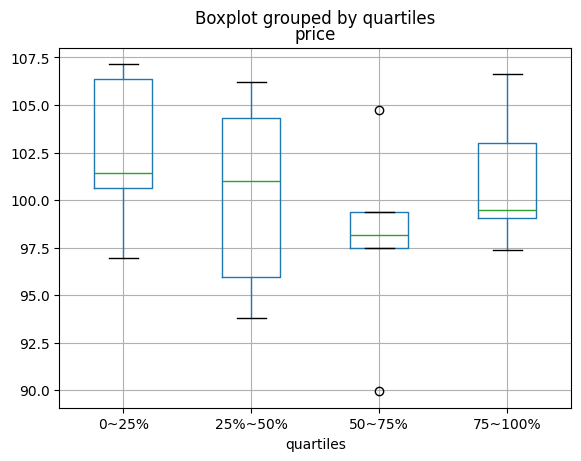

In [ ]:
### Plotting
#
df=pd.DataFrame(
    {
        "stratifying_var":np.random.uniform(0,100,20),
        "price":np.random.normal(100,5,20),
    }
)
df["quartiles"]=pd.qcut(
    df["stratifying_var"],4,labels=["0~25%","25%~50%","50~75%","75~100%"]
)
df.boxplot(column="price",by="quartiles")


In [ ]:
#reading multiple files to create a single dataframe
for i in range(3):
  data=pd.DataFrame(np.random.randn(10,4))
  data.to_csv("file_{}.csv".format(i))

files=["file_0.csv","file_1.csv","file_2.csv"]

result=pd.concat([pd.read_csv(f) for f in files ],ignore_index=True)

In [ ]:
#you can use the same approach to read all files matching a pattern, Here is an example uising glob

import glob
import os
files=glob.glob("file_*.csv")
result=pd.concat([pd.read_csv(f) for f in files],ignore_index=True)

In [ ]:
#Parsing date components in multi-columns
i=pd.date_range("20000101",periods=10000)
df=pd.DataFrame({"year":i.year,"month":i.month,"day":i.day})
df.head()

,year,month,day
0,2000,1,1
1,2000,1,2
2,2000,1,3
3,2000,1,4
4,2000,1,5


In [ ]:
%timeit pd.to_datetime(df.year*10000+df.month*100+df.day,format='%Y%m%d')
ds=df.apply(lambda x:"%04d%02d%02d"% (x["year"],x["month"],x["day"]),axis=1)
ds.head()
%timeit pd.to_datetime(ds)

7.11 ms ± 4.31 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
2.4 ms ± 86.2 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
data = """;;;;
   .....:  ;;;;
   .....:  ;;;;
   .....:  ;;;;
   .....:  ;;;;
   .....:  ;;;;
   .....: ;;;;
   .....:  ;;;;
   .....:  ;;;;
   .....: ;;;;
   .....: date;Param1;Param2;Param4;Param5
   .....:     ;m²;°C;m²;m
   .....: ;;;;
   .....: 01.01.1990 00:00;1;1;2;3
   .....: 01.01.1990 01:00;5;3;4;5
   .....: 01.01.1990 02:00;9;5;6;7
   .....: 01.01.1990 03:00;13;7;8;9
   .....: 01.01.1990 04:00;17;9;10;11
   .....: 01.01.1990 05:00;21;11;12;13
   .....: """
   .....:

In [ ]:
#option1 : pass rows explicityly to skip rows
from io import StringIO
pd.read_csv(
    StringIO(data),
    sep=";",
    skiprows=[11,12],
    index_col=0,
    parse_dates=True,
    header=10,
)

TypeError: initial_value must be str or None, not DataFrame

In [ ]:
### HDF Store
# Storing attributes to a group node
df=pd.DataFrame(np.random.randn(8,3))
store=pd.HDFStore("test.h5")
store.get_storer("df").attrs.my_attribute={"A":10}
store.get_storer("df").attrs.my_attribute

KeyError: 'No object named df in the file'

In [ ]:
##Computation
# correlation
df=pd.DataFrame(np.random.random(size=(100,5)))
corr_mat=df.corr()
mask=np.tril(np.ones_like(corr_mat,dtype=np.bool_),k=-1)
corr_mat.where(mask)

,0,1,2,3,4
0,NaN,NaN,NaN,NaN,NaN
1,0.023880,NaN,NaN,NaN,NaN
2,0.157154,-0.045870,NaN,NaN,NaN
3,0.013632,-0.037508,0.004565,NaN,NaN
4,0.035771,-0.243379,-0.081683,-0.042705,NaN


In [ ]:
#The method argument within DataFrame.corr can accept a callable in addition to the named
#correlation type,Here we compute the distance correlation matrix for a DataFrame object
def distcorr(x,y):
  n=len(x)
  a=np.zeros(shape=(n,n))
  b=np.zeros(shape=(n,n))
  for i in range(n):
    for j in range(i+1,n):
      a[i,j]=abs(x[i]-x[j])
      b[i,j]=abs(y[i]-y[j])

  a += a.T
  b += b.T
  a_bar=np.vstack([np.nanmean(a,axis=0)]*n)
  b_bar=np.vstack([np.nanmean(b,axis=0)]*n)
  A=a_bar-a_bar.T+np.full(shape=(n,n),fill_value=a_bar.mean())
  B=b-b_bar-b_bar.T +np.full(shape=(n,n),fill_value=b_bar.mean())
  cov_ab=np.sqrt(np.nansum(A*B))/n
  std_a=np.sqrt(np.sqrt(np.nansum(A**2))/n)
  std_b=np.sqrt(np.sqrt(np.nansum(B**2))/n)
  return cov_ab/std_a/std_b
df=pd.DataFrame(np.random.normal(size=(100,3)))
df.corr(method=distcorr)

,0,1,2
0,1.000000e+00,1.331541e-08,1.486759e-08
1,1.331541e-08,1.000000e+00,1.453191e-08
2,1.486759e-08,1.453191e-08,1.000000e+00


In [ ]:
##Timedeltas
# Using timedeltas
import datetime
s=pd.Series(pd.date_range("2012-1-1",periods=3,freq="D"))
s-s.max()

,0
0,-2 days
1,-1 days
2,0 days


In [ ]:
s.max() -s

,0
0,2 days
1,1 days
2,0 days


In [ ]:
s-datetime.datetime(2011,1,1,3,5)

,0
0,364 days 20:55:00
1,365 days 20:55:00
2,366 days 20:55:00


In [ ]:
s+datetime.timedelta(minutes=5)

,0
0,2012-01-01 00:05:00
1,2012-01-02 00:05:00
2,2012-01-03 00:05:00


In [ ]:
datetime.datetime(2011,1,1,3,5)-s

,0
0,-365 days +03:05:00
1,-366 days +03:05:00
2,-367 days +03:05:00


In [ ]:
datetime.datetime(2011,1,1,3,5)-s

,0
0,-365 days +03:05:00
1,-366 days +03:05:00
2,-367 days +03:05:00


In [ ]:
datetime.timedelta(minutes=5)+s

,0
0,2012-01-01 00:05:00
1,2012-01-02 00:05:00
2,2012-01-03 00:05:00


In [ ]:
#Adding and subtracting deltas and dates
deltas=pd.Series([datetime.timedelta(days=i) for i in range(3)])
df=pd.DataFrame({"A":s,"B":deltas})
df

,A,B
0,2012-01-01,0 days
1,2012-01-02,1 days
2,2012-01-03,2 days


In [ ]:
df["New Dates"]=df["A"]+df["B"]
df["Delta"]=df["A"]-df["New Dates"]
df

,A,B,New Dates,Delta
0,2012-01-01,0 days,2012-01-01,0 days
1,2012-01-02,1 days,2012-01-03,-1 days
2,2012-01-03,2 days,2012-01-05,-2 days


In [ ]:
df.dtypes

,0
A,datetime64[ns]
B,timedelta64[ns]
New Dates,datetime64[ns]
Delta,timedelta64[ns]


In [ ]:
#another example
y=s-s.shift()
y

,0
0,NaT
1,1 days
2,1 days


In [ ]:
y[1]=np.nan
y

,0
0,NaT
1,NaT
2,1 days


In [ ]:
###Creating example data
def expand_grid(data_dict):
  rows=itertools.product(*data_dict.values())
  return pd.DataFrame.from_records(rows,columns=data_dict.keys())

df=expand_grid(
    {"heigt":[60,70],"weight":[100,140,180],"sex":["Male","Female"]}

)
df

NameError: name 'itertools' is not defined

In [ ]:
###Constant Series
#to assess if a series has a constant value, we check if series.nunique() <=1

v=s.to_numpy()
is_constant=v.shape[0]==0 or (s[0]==s).all()

In [ ]:
v=s.dropna().to_numpy()
is_constan=v.shape[0]==0 or (s[0]==s).all()

In [ ]:
v=s.to_numpy()
is_constant==v.shape[0]==0 or(s[0]==s).all() or not pd.notna(v).any()

False